In [191]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [192]:
df= pd.read_csv('../datasets/kentucky_real_estate.csv')

df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,NaN,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,NaN,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,NaN,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,NaN,2.0,2.0,2.0,NaN
4,single_family,NaN,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,NaN


# EDA

In [193]:
df.shape

(8502, 12)

In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8502 entries, 0 to 8501
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   type             8502 non-null   object 
 1   sub_type         535 non-null    object 
 2   text             8380 non-null   object 
 3   listPrice        8487 non-null   float64
 4   sqft             7868 non-null   float64
 5   stories          6708 non-null   float64
 6   beds             8097 non-null   float64
 7   baths            7804 non-null   float64
 8   baths_full       7997 non-null   float64
 9   baths_full_calc  8002 non-null   float64
 10  garage           5605 non-null   float64
 11  year_built       6741 non-null   float64
dtypes: float64(9), object(3)
memory usage: 797.2+ KB


In [195]:
df.describe()

,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
count,8.487000e+03,7868.000000,6708.000000,8097.000000,7804.000000,7997.000000,8002.000000,5605.000000,6741.000000
mean,3.914692e+05,2150.625953,1.535033,3.327158,2.426064,2.113918,2.114846,11.912043,1992.965287
std,4.105916e+05,1335.424356,0.556187,1.400185,1.251852,0.972690,0.972658,708.711176,35.021180
min,1.000000e+00,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1784.000000
25%,2.200000e+05,1377.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1972.000000
50%,3.179000e+05,1850.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2003.000000
75%,4.500000e+05,2600.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,2024.000000
max,2.000000e+07,42686.000000,6.000000,41.000000,30.000000,30.000000,30.000000,53050.000000,2027.000000


In [196]:
# drop duplicated



In [197]:
df.duplicated().sum()

np.int64(49)

In [198]:
# separate num null cols and categorical cols

num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

In [199]:
df.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'sqft', 'stories', 'beds',
       'baths', 'baths_full', 'baths_full_calc', 'garage', 'year_built'],
      dtype='object')

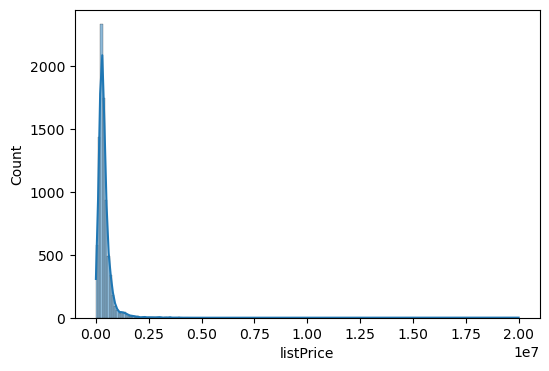

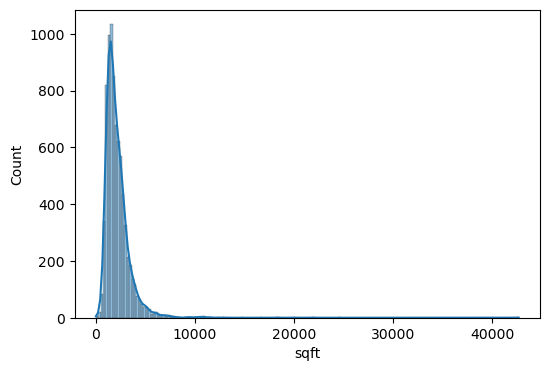

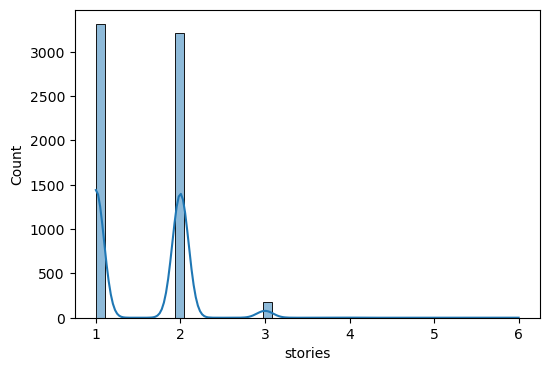

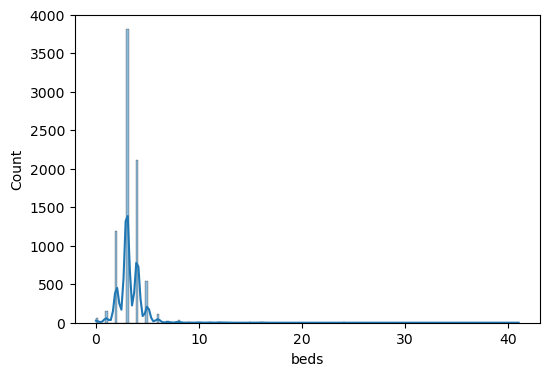

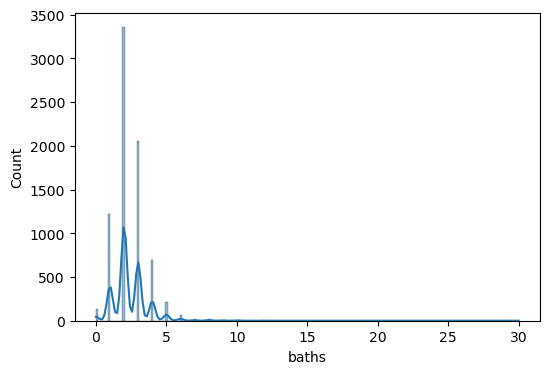

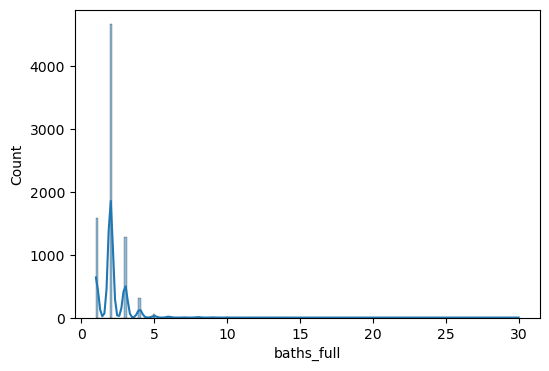

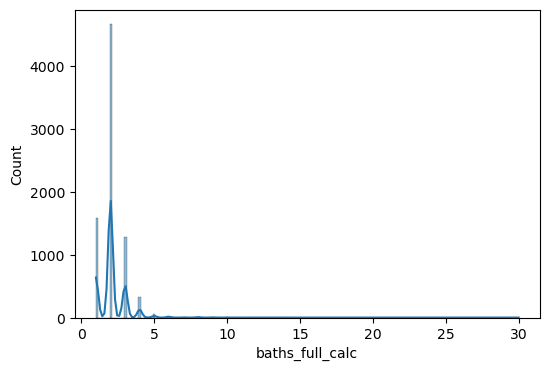

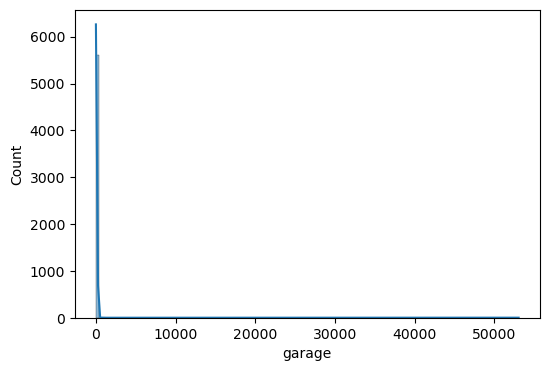

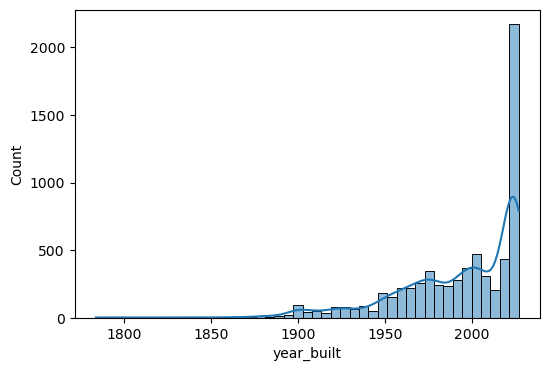

In [200]:

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df,x=df[col],kde=True)

<Axes: xlabel='type'>

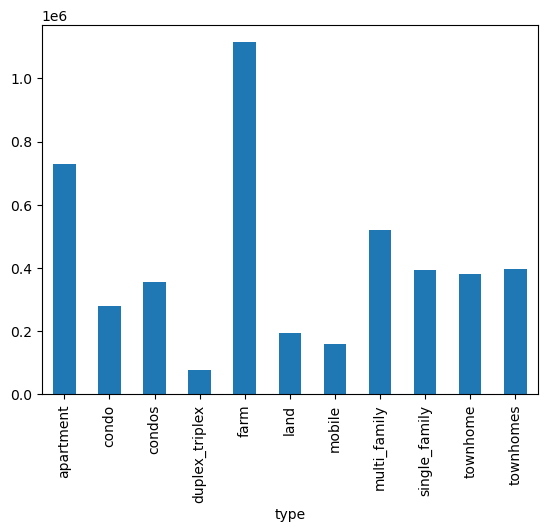

In [201]:
df.groupby(['type'])['listPrice'].mean().plot(kind='bar')

<Axes: xlabel='type'>

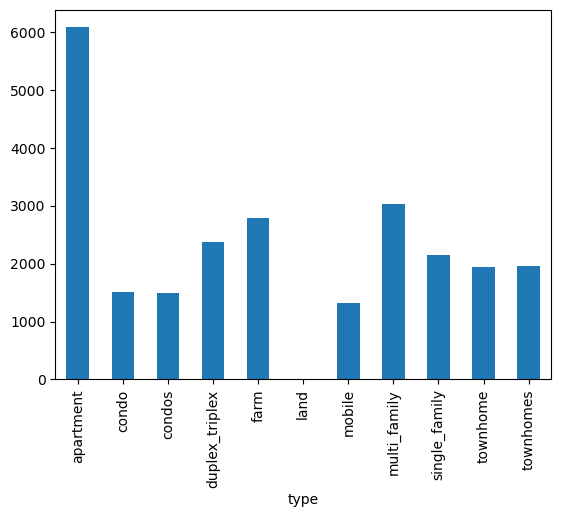

In [202]:
df.groupby(['type'])['sqft'].mean().plot(kind='bar')

In [203]:
df.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,NaN,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,NaN,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,NaN,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,NaN,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,NaN,2.0,2.0,2.0,NaN
4,single_family,NaN,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,NaN


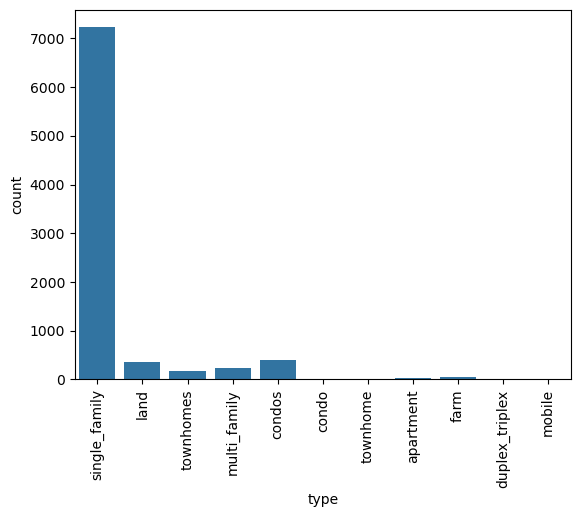

In [204]:
sns.countplot(df,x=df['type'])
plt.xticks(rotation=90)
plt.show()

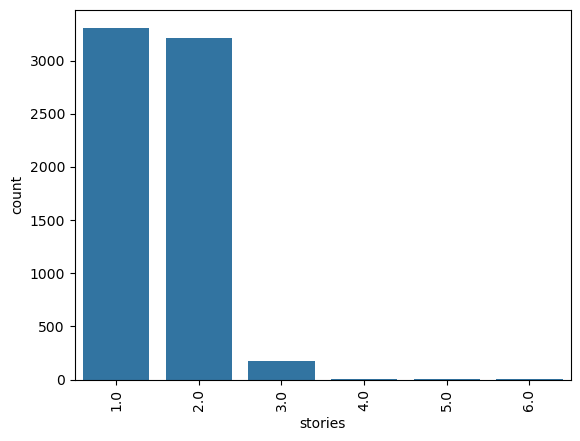

In [205]:
sns.countplot(df,x=df['stories'])
plt.xticks(rotation=90)
plt.show()

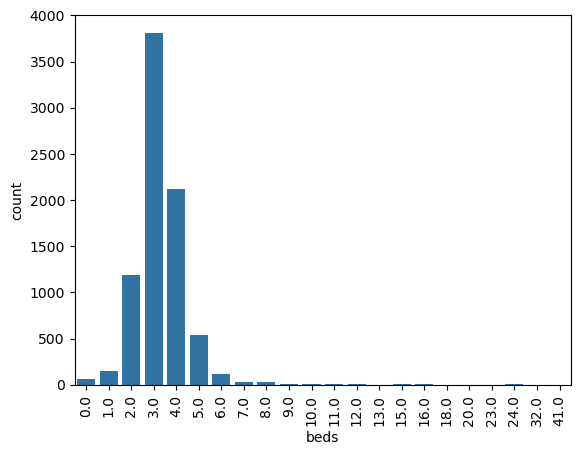

In [206]:
sns.countplot(df,x=df['beds'])
plt.xticks(rotation=90)
plt.show()

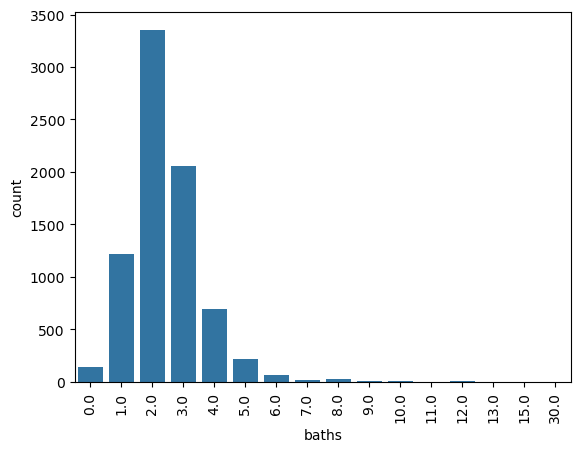

In [207]:
sns.countplot(df,x=df['baths'])
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='garage'>

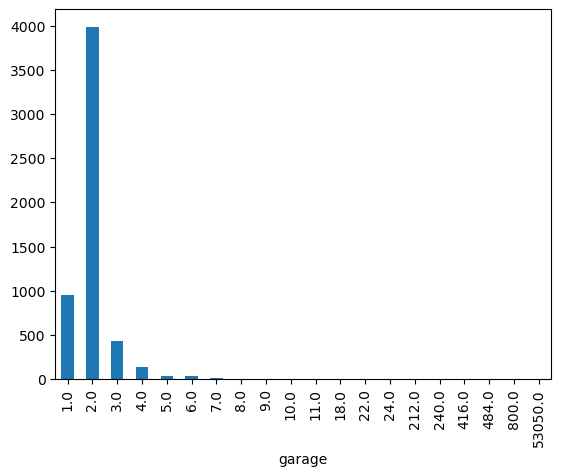

In [208]:
df.groupby(['garage'])['listPrice'].count().plot(kind='bar')

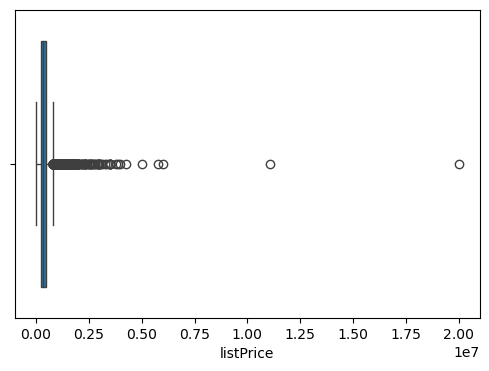

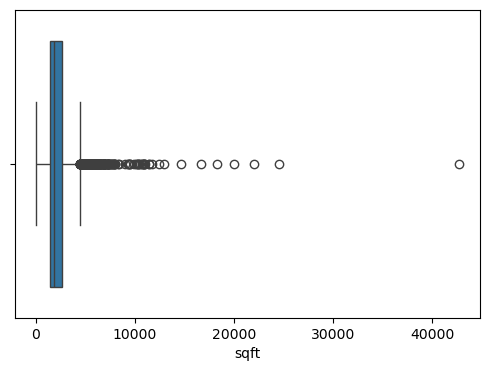

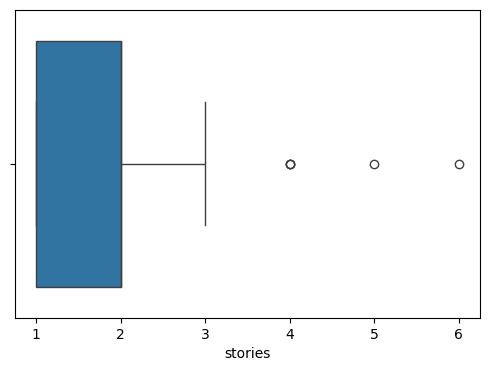

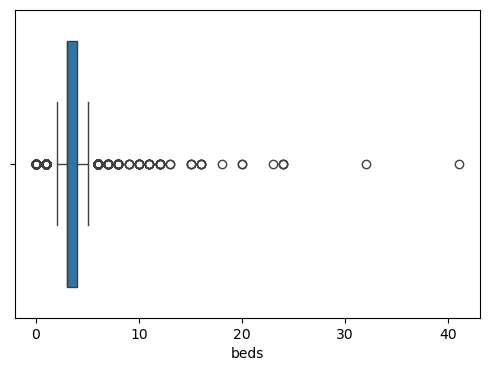

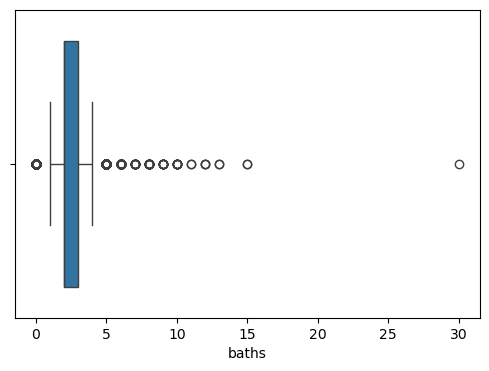

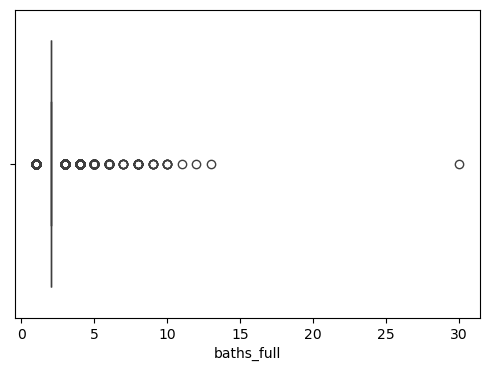

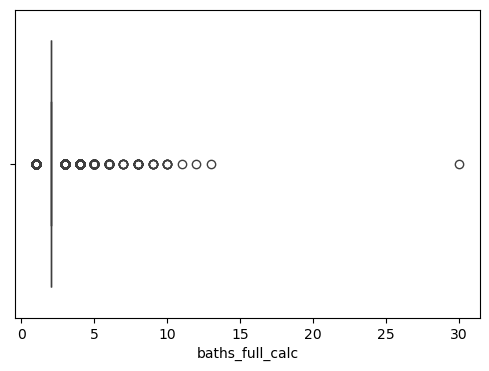

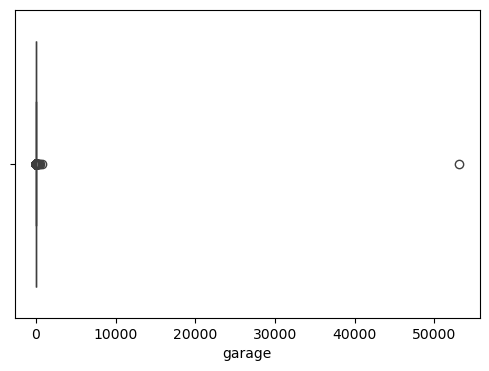

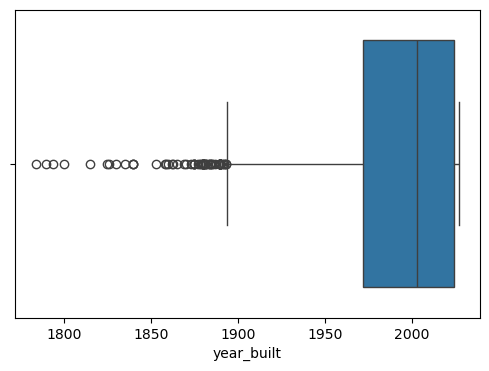

In [209]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df,x=df[col])

<Axes: >

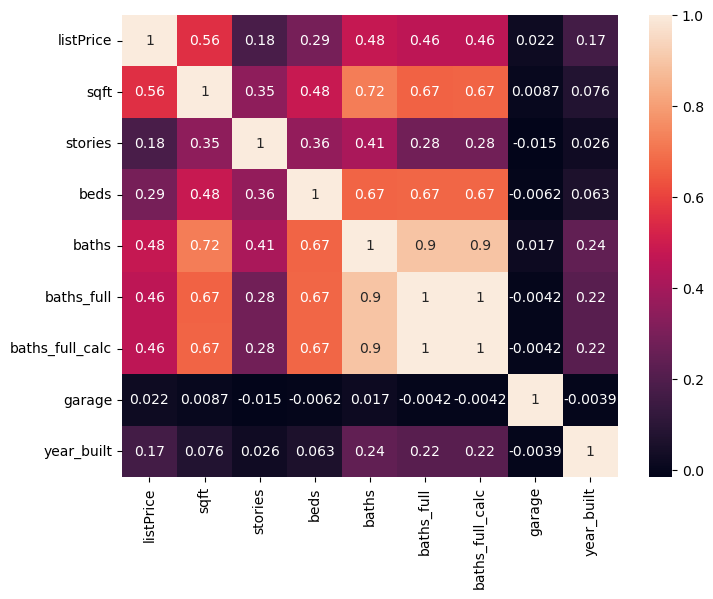

In [210]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data Cleaning and Pre-Processing

In [211]:

df_cleaned=df.copy()

print(df_cleaned.isnull().sum()[df_cleaned.isnull().sum() > 0])

sub_type           7967
text                122
listPrice            15
sqft                634
stories            1794
beds                405
baths               698
baths_full          505
baths_full_calc     500
garage             2897
year_built         1761
dtype: int64


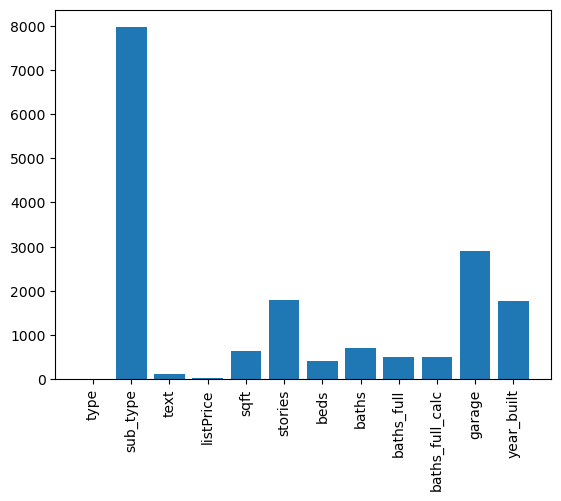

In [212]:
plt.bar(df_cleaned.columns, df_cleaned.isnull().sum())
plt.xticks(rotation=90)
plt.show()

In [213]:
df_cleaned[df_cleaned.duplicated()].head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
571,townhomes,townhouse,New construction 3 bed 2.5 bath townhouse with...,266500.0,1778.0,NaN,3.0,3.0,2.0,2.0,1.0,2026.0
2127,townhomes,townhouse,"Welcome to the highly sought-after, upscale ne...",349000.0,2027.0,NaN,3.0,3.0,2.0,2.0,1.0,2025.0
2186,single_family,NaN,Attention Investors! Don't miss out on this op...,900000.0,978.0,1.0,3.0,1.0,1.0,1.0,NaN,1997.0
2467,condos,condo,The Boardwalk Residences at Ovation feature 88...,2320000.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2023.0
2899,condos,condo,The Boardwalk Residences at Ovation are locate...,1095000.0,NaN,1.0,2.0,2.0,2.0,2.0,1.0,2023.0


In [214]:
df_cleaned = df_cleaned.drop_duplicates()

In [215]:
# separate num null cols and categorical cols

num_cols = df_cleaned.select_dtypes(include=['int64','float64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

In [216]:
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df[num_cols].median())
df_cleaned[cat_cols] = df_cleaned[cat_cols].fillna("Unknown")

In [217]:
df_cleaned.head()

,type,sub_type,text,listPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,year_built
0,single_family,Unknown,Welcome to this beautifully maintained ranch h...,550000.0,3460.0,2.0,6.0,4.0,4.0,4.0,2.0,2003.0
1,single_family,Unknown,New construction by Fischer Homes in the beaut...,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2.0,2026.0
2,single_family,Unknown,"Beautiful 5-bedroom, 4.5-bath home located in ...",859990.0,3918.0,2.0,5.0,5.0,4.0,4.0,2.0,2023.0
3,single_family,Unknown,If you're looking for convenient living on one...,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2.0,2003.0
4,single_family,Unknown,This beautiful ranch home with a basement is l...,339900.0,3200.0,1.0,5.0,3.0,3.0,3.0,2.0,2003.0


In [218]:
df_cleaned.shape

(8453, 12)

In [219]:
df_cleaned.loc[0, 'text']

"Welcome to this beautifully maintained ranch home nestled in the desirable Nature Cove neighborhood of Mt Washington, offering over 3, 400 square feet of finished living space designed for comfort, flexibility, and entertaining. Situated on a spacious 0.64-acre lot, this 6-bedroom, 4-bath home provides the perfect blend of indoor and outdoor living. The fenced backyard offers plenty of room to roam, play, garden, or simply relax and enjoy the peaceful surroundings. Step inside through the foyer and immediately notice the inviting living room featuring a vaulted ceiling and a stunning fireplace that creates a warm and cozy focal point. Just off the living room, a door leads to a raised deck overlooking the expansive backyard - ideal for morning coffee or evening gatherings. The open flow between the living and dining rooms makes hosting friends and family effortless. The eat-in kitchen offers a charming breakfast nook and a convenient peninsula with counter seating, perfect for quick m

In [220]:
#removed unnecessery data cols

df_cleaned.drop(columns=['text','sub_type','baths_full_calc'],inplace=True)

In [221]:
df_cleaned.head()

,type,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built
0,single_family,550000.0,3460.0,2.0,6.0,4.0,4.0,2.0,2003.0
1,single_family,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2026.0
2,single_family,859990.0,3918.0,2.0,5.0,5.0,4.0,2.0,2023.0
3,single_family,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2003.0
4,single_family,339900.0,3200.0,1.0,5.0,3.0,3.0,2.0,2003.0


In [222]:
df_cleaned['type'].value_counts()

type
single_family     7201
condos             381
land               356
multi_family       230
townhomes          169
farm                46
apartment           20
mobile              18
condo               17
townhome            12
duplex_triplex       3
Name: count, dtype: int64

In [223]:
# clean categorys data names

df_cleaned['type'] = df_cleaned['type'].replace({
    'condos': 'condo',
    'townhomes': 'townhome'
})

In [224]:
type_counts = df_cleaned['type'].value_counts()

rare_types = type_counts[type_counts < 50].index

df_cleaned['type'] = df_cleaned['type'].replace(rare_types, 'other')

In [225]:
# covert categorical columns into numeric values

In [226]:
#one hot encoding
df_cleaned['type'].value_counts()

type
single_family    7201
condo             398
land              356
multi_family      230
townhome          181
other              87
Name: count, dtype: int64

In [227]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['type'], drop_first=False, dtype=int)

In [228]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome
0,550000.0,3460.0,2.0,6.0,4.0,4.0,2.0,2003.0,0,0,0,0,1,0
1,501029.0,3146.0,2.0,4.0,3.0,2.0,2.0,2026.0,0,0,0,0,1,0
2,859990.0,3918.0,2.0,5.0,5.0,4.0,2.0,2023.0,0,0,0,0,1,0
3,537100.0,1987.0,1.0,2.0,2.0,2.0,2.0,2003.0,0,0,0,0,1,0
4,339900.0,3200.0,1.0,5.0,3.0,3.0,2.0,2003.0,0,0,0,0,1,0


In [229]:
df_cleaned=df_cleaned.astype(int)

In [230]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome
0,550000,3460,2,6,4,4,2,2003,0,0,0,0,1,0
1,501029,3146,2,4,3,2,2,2026,0,0,0,0,1,0
2,859990,3918,2,5,5,4,2,2023,0,0,0,0,1,0
3,537100,1987,1,2,2,2,2,2003,0,0,0,0,1,0
4,339900,3200,1,5,3,3,2,2003,0,0,0,0,1,0


# Feature Engineeringand Extraction

In [231]:
# create catgoites as per price of properties

# specific bins, ending with infinity
bins = [0, 150000, 300000, 500000, np.inf]

# Labels must have one less item than the number of bin edges
labels = ["Affordable", "Mid-Range", "Upper-mid Range", "Luxury"]

# Example usage
df_cleaned['category'] = pd.cut(df_cleaned['listPrice'], bins=bins, labels=labels)


In [232]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome,category
0,550000,3460,2,6,4,4,2,2003,0,0,0,0,1,0,Luxury
1,501029,3146,2,4,3,2,2,2026,0,0,0,0,1,0,Luxury
2,859990,3918,2,5,5,4,2,2023,0,0,0,0,1,0,Luxury
3,537100,1987,1,2,2,2,2,2003,0,0,0,0,1,0,Luxury
4,339900,3200,1,5,3,3,2,2003,0,0,0,0,1,0,Upper-mid Range


In [233]:
#one encofing categories
df_cleaned = pd.get_dummies(df_cleaned, columns=['category'], drop_first=False, dtype=int)

In [234]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome,category_Affordable,category_Mid-Range,category_Upper-mid Range,category_Luxury
0,550000,3460,2,6,4,4,2,2003,0,0,0,0,1,0,0,0,0,1
1,501029,3146,2,4,3,2,2,2026,0,0,0,0,1,0,0,0,0,1
2,859990,3918,2,5,5,4,2,2023,0,0,0,0,1,0,0,0,0,1
3,537100,1987,1,2,2,2,2,2003,0,0,0,0,1,0,0,0,0,1
4,339900,3200,1,5,3,3,2,2003,0,0,0,0,1,0,0,0,1,0


In [235]:
import datetime
current_year = datetime.datetime.now().year

# Create an 'age' column instead of using 'year_built'
df_cleaned['house_age'] = current_year - df_cleaned['year_built']

In [237]:
df_cleaned.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome,category_Affordable,category_Mid-Range,category_Upper-mid Range,category_Luxury,house_age
0,550000,3460,2,6,4,4,2,2003,0,0,0,0,1,0,0,0,0,1,23
1,501029,3146,2,4,3,2,2,2026,0,0,0,0,1,0,0,0,0,1,0
2,859990,3918,2,5,5,4,2,2023,0,0,0,0,1,0,0,0,0,1,3
3,537100,1987,1,2,2,2,2,2003,0,0,0,0,1,0,0,0,0,1,23
4,339900,3200,1,5,3,3,2,2003,0,0,0,0,1,0,0,0,1,0,23


In [238]:
df.drop(columns=['year_built'],inplace=True)

In [241]:
#scaling and Standerdizaton

df_final=df_cleaned.copy()

In [242]:
df_final.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome,category_Affordable,category_Mid-Range,category_Upper-mid Range,category_Luxury,house_age
0,550000,3460,2,6,4,4,2,2003,0,0,0,0,1,0,0,0,0,1,23
1,501029,3146,2,4,3,2,2,2026,0,0,0,0,1,0,0,0,0,1,0
2,859990,3918,2,5,5,4,2,2023,0,0,0,0,1,0,0,0,0,1,3
3,537100,1987,1,2,2,2,2,2003,0,0,0,0,1,0,0,0,0,1,23
4,339900,3200,1,5,3,3,2,2003,0,0,0,0,1,0,0,0,1,0,23


In [243]:
from sklearn.preprocessing import StandardScaler

# Features to scale (don't scale your 0/1 dummy columns!)
features_to_scale = ['sqft', 'stories', 'beds', 'baths', 'baths_full', 'garage', 'house_age']

scaler = StandardScaler()
df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])


In [244]:
df_final.head()

,listPrice,sqft,stories,beds,baths,baths_full,garage,year_built,type_condo,type_land,type_multi_family,type_other,type_single_family,type_townhome,category_Affordable,category_Mid-Range,category_Upper-mid Range,category_Luxury,house_age
0,550000,1.030686,0.694051,1.960578,1.333373,2.000950,-0.011393,2003,0,0,0,0,1,0,0,0,0,1,-0.256420
1,501029,0.787183,0.694051,0.501065,0.503891,-0.113700,-0.011393,2026,0,0,0,0,1,0,0,0,0,1,-0.987197
2,859990,1.385860,0.694051,1.230822,2.162856,2.000950,-0.011393,2023,0,0,0,0,1,0,0,0,0,1,-0.891878
3,537100,-0.111609,-1.196031,-0.958447,-0.325591,-0.113700,-0.011393,2003,0,0,0,0,1,0,0,0,0,1,-0.256420
4,339900,0.829059,-1.196031,1.230822,0.503891,0.943625,-0.011393,2003,0,0,0,0,1,0,0,0,1,0,-0.256420


In [248]:

corr_matrix = df_final.corr()
# Focus on how everything correlates with listPrice
price_correlations = corr_matrix['listPrice'].sort_values(ascending=False)

print(price_correlations)


listPrice                   1.000000
category_Luxury             0.561601
sqft                        0.494826
baths                       0.458855
baths_full                  0.422056
beds                        0.275504
year_built                  0.140450
stories                     0.116615
type_other                  0.099605
type_multi_family           0.053635
type_single_family          0.017599
garage                      0.015897
type_townhome               0.003653
category_Upper-mid Range   -0.001835
type_condo                 -0.025771
type_land                  -0.100076
house_age                  -0.140450
category_Affordable        -0.272694
category_Mid-Range         -0.276249
Name: listPrice, dtype: float64


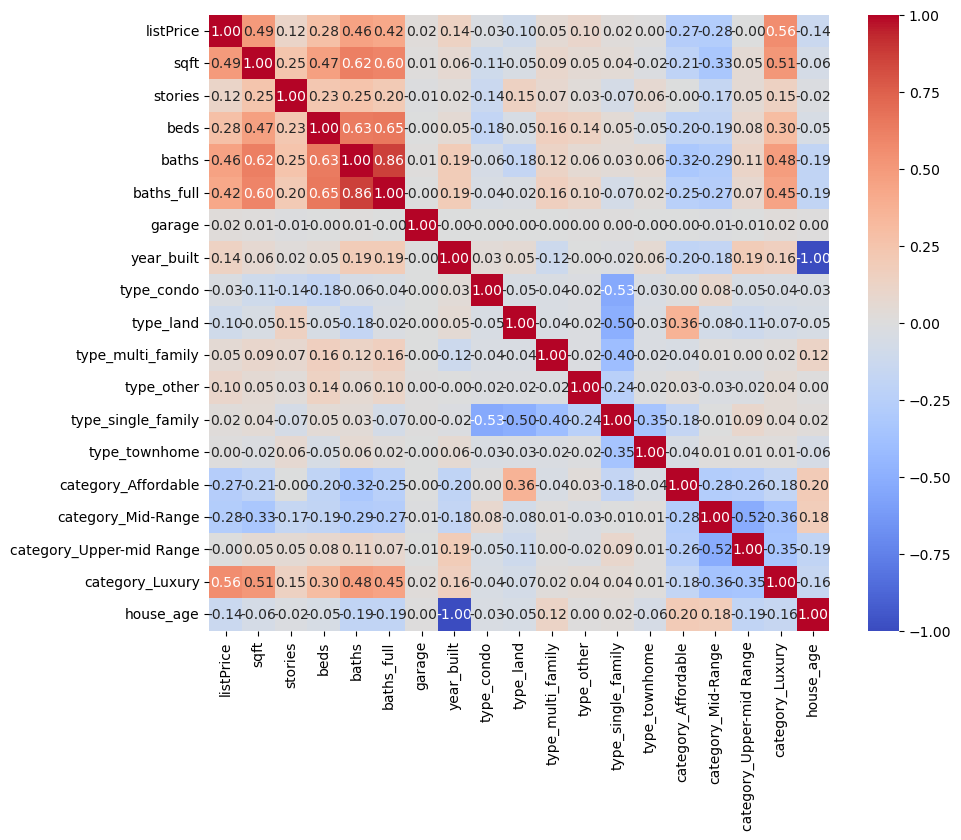

In [249]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


In [246]:
X=df_final.drop(columns=['listPrice'])
Y=df_final['listPrice']



In [247]:
print(X)
print(Y)

          sqft   stories      beds     baths  baths_full    garage  \
0     1.030686  0.694051  1.960578  1.333373    2.000950 -0.011393   
1     0.787183  0.694051  0.501065  0.503891   -0.113700 -0.011393   
2     1.385860  0.694051  1.230822  2.162856    2.000950 -0.011393   
3    -0.111609 -1.196031 -0.958447 -0.325591   -0.113700 -0.011393   
4     0.829059 -1.196031  1.230822  0.503891    0.943625 -0.011393   
...        ...       ...       ...       ...         ...       ...   
8497 -0.542780  0.694051 -0.228691 -0.325591   -0.113700 -0.011393   
8498  0.829059  0.694051  1.960578  1.333373    2.000950 -0.007927   
8499 -0.479966 -1.196031 -0.228691  0.503891    0.943625 -0.013126   
8500 -1.466387  0.694051 -1.688204 -1.155073   -1.171026 -0.011393   
8501  0.533598  0.694051  0.501065  0.503891    0.943625 -0.011393   

      year_built  type_condo  type_land  type_multi_family  type_other  \
0           2003           0          0                  0           0   
1          

In [254]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Identify categorical columns
cat_cols = [col for col in df_final.columns if 'type_' in col or 'category_' in col]
alpha = 0.05  # Significance threshold
results = []

# 2. Automated Loop
for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        col1, col2 = cat_cols[i], cat_cols[j]
        
        table = pd.crosstab(df_final[col1], df_final[col2])
        
        try:
            _, p, _, _ = chi2_contingency(table)
            
            # 3. Logic for 'Keep' or 'Drop' based on p-value
            if p <= alpha:
                status = "Reject Null (Keep Feature)"
            else:
                status = "Accept Null (Drop Feature)"
                
            results.append({
                'Variable 1': col1,
                'Variable 2': col2,
                'P-Value': round(p, 6),
                'Status': status
            })
        except ValueError:
            continue

# 4. Display sorted results
results_df = pd.DataFrame(results).sort_values(by='P-Value')
print(results_df[['Variable 1','Variable 2','P-Value', 'Status']])


                  Variable 1                Variable 2   P-Value  \
44  category_Upper-mid Range           category_Luxury  0.000000   
16                 type_land           category_Luxury  0.000000   
15                 type_land  category_Upper-mid Range  0.000000   
14                 type_land        category_Mid-Range  0.000000   
13                 type_land       category_Affordable  0.000000   
24                type_other        type_single_family  0.000000   
11                 type_land        type_single_family  0.000000   
30        type_single_family             type_townhome  0.000000   
43        category_Mid-Range           category_Luxury  0.000000   
31        type_single_family       category_Affordable  0.000000   
6                 type_condo        category_Mid-Range  0.000000   
39       category_Affordable        category_Mid-Range  0.000000   
40       category_Affordable  category_Upper-mid Range  0.000000   
3                 type_condo        type_single_